In [1]:
# ====================================================================
# 0. imports & reproducibility
# ====================================================================
import pandas as pd, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from tcn import TCN
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from pathlib import Path
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adamax, Nadam, Adadelta

rng = np.random.default_rng(787)
tf.keras.utils.set_random_seed(787)
tf.debugging.enable_check_numerics()          # crash early on NaN/Inf

INFO:tensorflow:Enabled check-numerics callback in thread MainThread


In [2]:
# ------------------------------------------------------------------
# files you want to merge  (add as many as you like)
# ------------------------------------------------------------------
FILES = [
    "previous_dv0_withoutstraw_sipCAdded.xlsx", 
    "previous_dv0_withstraw_sipCAdded.xlsx",
    "dv0_withoutstraw_sipCAdded.xlsx",
     
    "dv0_withstraw_sipCAdded.xlsx",
                       # ← put your second file name here
    # "third_file.xlsx",
]

In [3]:
# ------------------------------------------------------------------
# read & re-index
# ------------------------------------------------------------------
dfs          = []
next_offset  = 0          # keeps track of the next free Participant_ID

for fp in FILES:
    fp = Path(fp)
    df = pd.read_excel(fp)

    # current file's min/max before shifting (optional print for sanity)
    old_min, old_max = df["Participant_ID"].min(), df["Participant_ID"].max()
    print(f"{fp.name}: original IDs {old_min} … {old_max}")

    # shift IDs so they don't collide with previous files
    df["Participant_ID"] += next_offset

    # update next_offset for the *next* file
    next_offset = df["Participant_ID"].max() + 1

    # done
    dfs.append(df)
    print(f"   shifted to {df['Participant_ID'].min()} … {df['Participant_ID'].max()}")


previous_dv0_withoutstraw_sipCAdded.xlsx: original IDs 6 … 62
   shifted to 6 … 62
previous_dv0_withstraw_sipCAdded.xlsx: original IDs 9 … 59
   shifted to 72 … 122
dv0_withoutstraw_sipCAdded.xlsx: original IDs 1 … 14
   shifted to 124 … 137
dv0_withstraw_sipCAdded.xlsx: original IDs 1 … 5
   shifted to 139 … 143


In [4]:
# ------------------------------------------------------------------
# combined DataFrame
# ------------------------------------------------------------------
df_all = pd.concat(dfs, ignore_index=True)
print("\nMerged dataframe shape:", df_all.shape)
print("Global Participant_ID range:", df_all["Participant_ID"].min(),
      "…", df_all["Participant_ID"].max())


Merged dataframe shape: (134974, 82)
Global Participant_ID range: 6 … 143


In [5]:
df_all

,Unnamed: 0,Time,Zone_0,Zone_1,Zone_2,Zone_3,Zone_4,Zone_5,Zone_6,Zone_7,...,Container_Weight,drink,temp,prev,next,sip_start,sip_end,sip_id,dV,TOTAL_SIP_TIME
0,0,1747823631000,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
1,1,1747823631200,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
2,2,1747823631400,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
3,3,1747823631600,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
4,4,1747823631800,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134969,4024,1750725782000,1595,1593,1578,1577,1573,1573,1572,1564,...,7.7,water,n,0,0,False,False,5,0.0,0
134970,4025,1750725782200,1595,1593,1578,1577,1573,1573,1572,1564,...,7.7,water,n,0,0,False,False,5,0.0,0
134971,4026,1750725782400,1595,1591,1578,1577,1574,1573,1575,1564,...,7.7,water,n,0,0,False,False,5,0.0,0
134972,4027,1750725782600,1595,1591,1578,1577,1574,1573,1575,1564,...,7.7,water,n,0,0,False,False,5,0.0,0


In [6]:
df = df_all

In [7]:
# print("Label stats  (raw, before scaling)")
# print("  min :", y.min())
# print("  #zeros :", (y == 0).sum())
# print("  any negative? ", (y < 0).any())

In [8]:

# --------------------------------------------------------------------
# user settings
# --------------------------------------------------------------------

BATCH      = 8                                   # 1 = ragged, >1 = padded


In [9]:
# # ====================================================================
# # 1. load data  ➜  X(list of (T,64)), y(array)   – SKIP zero-volume sips
# # ====================================================================
# df = df[df["Label"] == 1]                        # keep only annotated frames

# feature_cols = df.columns[2:66]
# seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

# X, y = [], []
# skip_count = 0

# for _, g in df.groupby(seq_keys, sort=False):
#     dV = float(g[label_col].iloc[0])
#     if dV == 0.0:                                # ← drop empty sip
#         skip_count += 1
#         continue
#     X.append(g[feature_cols].to_numpy(np.float32))   # (T,64)
#     y.append(dV)

# y = np.asarray(y, np.float32)
# X = np.array(X, dtype=object)   # each element is still a (T,64) array
# print(f"Total sips kept : {len(X)}")
# print(f"Zero-volume skipped : {skip_count}")
# print("Label stats  → min:", y.min(), "max:", y.max())

In [10]:
# # ====================================================================
# # 1. load data  ➜  X(list of (T,64)), y(array) – SKIP zero-volume sips – APPLY AUGMENTATION
# # ====================================================================

# df = df[df["Label"] == 1]                        # keep only annotated frames

# feature_cols = df.columns[2:66]
# seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

# # --- Augmentation Functions ---
# def add_gaussian_noise(sip, std_dev=0.01):
#     """Add Gaussian noise to the sip (T, 64)."""
#     noise = np.random.normal(0, std_dev, sip.shape)
#     return sip + noise

# def flip_horizontal(sip):
#     """Flip 8x8 frames horizontally for all time steps in sip (T, 64)."""
#     flipped = []
#     for frame in sip:
#         frame_8x8 = frame.reshape(8, 8)
#         flipped_frame = np.fliplr(frame_8x8).flatten()
#         flipped.append(flipped_frame)
#     return np.array(flipped, dtype=np.float32)

# # --- You control this threshold: sips longer than this will be augmented
# AUGMENT_IF_LONGER_THAN = 15  # You can change this

# # --- Main data list
# X, y = [], []
# skip_count = 0

# for _, g in df.groupby(seq_keys, sort=False):
#     dV = float(g[label_col].iloc[0])
#     if dV == 0.0:
#         skip_count += 1
#         continue

#     sip_frames = g[feature_cols].to_numpy(np.float32)  # shape (T, 64)
#     T = len(sip_frames)

#     X.append(sip_frames)
#     y.append(dV)

#     # Augment only if sip is long
#     if T > AUGMENT_IF_LONGER_THAN:
#         # 1. Add Gaussian noise
#         noisy_sip = add_gaussian_noise(sip_frames)
#         X.append(noisy_sip)
#         y.append(dV)

#         # 2. Flip horizontally
#         flipped_sip = flip_horizontal(sip_frames)
#         X.append(flipped_sip)
#         y.append(dV)
# X = np.array(X, dtype=object)   # each sip is still (T, 64)
# y = np.array(y, dtype=np.float32)

# print(f"Total sips kept (including augmented): {len(X)}")
# print(f"Zero-volume skipped : {skip_count}")
# print("Label stats  → min:", min(y), "max:", max(y))


In [11]:
# # ====================================================================
# # 1. load data  ➜  X(list of (T,64)), y(array) – SKIP zero-volume sips – APPLY AUGMENTATION
# # ====================================================================


# df = df[df["Label"] == 1]  # keep only annotated frames

# feature_cols = df.columns[2:66]
# seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

# # --- Augmentation Functions ---
# def add_gaussian_noise(sip, std_dev=40):
#     """Add Gaussian noise to the sip (T, 64)."""
#     noise = np.random.normal(0, std_dev, sip.shape)
#     return sip + noise

# def flip_horizontal(sip):
#     """Flip 8x8 frames horizontally for all time steps in sip (T, 64)."""
#     flipped = []
#     for frame in sip:
#         frame_8x8 = frame.reshape(8, 8)
#         flipped_frame = np.fliplr(frame_8x8).flatten()
#         flipped.append(flipped_frame)
#     return np.array(flipped, dtype=np.float32)

# # --- Thresholds you control
# AUGMENT_IF_LONGER_THAN = 15           # Regular augmentation if T > this
# MORE_AUGMENT_IF_LONGER_THAN = 20      # Extra augmentation if T > this
# NUM_EXTRA_NOISY_COPIES = 5            # Number of additional noise versions for long sips
# NUM_EXTRA_NOISY_COPIES_2 =3
# MORE_AUGMENT_IF_LONGER_THAN_2= 34
# # --- Main data list
# X, y = [], []
# skip_count = 0

# for _, g in df.groupby(seq_keys, sort=False):
#     dV = float(g[label_col].iloc[0])
#     if dV == 0.0:
#         skip_count += 1
#         continue

#     sip_frames = g[feature_cols].to_numpy(np.float32)  # shape (T, 64)
#     T = len(sip_frames)

#     # Original sip
#     X.append(sip_frames)
#     y.append(dV)

#     # Moderate-length sip → 1 noise + 1 flip
#     if T > AUGMENT_IF_LONGER_THAN:
#         noisy_sip = add_gaussian_noise(sip_frames)
#         X.append(noisy_sip)
#         y.append(dV)

#         flipped_sip = flip_horizontal(sip_frames)
#         X.append(flipped_sip)
#         y.append(dV)

#     # Extra-long sip → multiple noise augmentations
#     if T > MORE_AUGMENT_IF_LONGER_THAN:
#         for _ in range(NUM_EXTRA_NOISY_COPIES):
#             noisy_version = add_gaussian_noise(sip_frames)
#             X.append(noisy_version)
#             y.append(dV)
#     if T > MORE_AUGMENT_IF_LONGER_THAN_2:
#         for _ in range(NUM_EXTRA_NOISY_COPIES_2):
#             noisy_version = add_gaussian_noise(sip_frames)
#             X.append(noisy_version)
#             y.append(dV)        

# # Final conversion to array
# X = np.array(X, dtype=object)   # each sip is still (T, 64)
# y = np.array(y, dtype=np.float32)

# print(f"Total sips kept (including augmented): {len(X)}")
# print(f"Zero-volume skipped : {skip_count}")
# print("Label stats  → min:", min(y), "max:", max(y))



In [12]:
# # # ====================================================================
# # # 1. load data  ➜  X(list of (T,64)), y(array) – SKIP zero-volume sips – APPLY AUGMENTATION
# # # ====================================================================

# df = df[df["Label"] == 1]  # keep only annotated frames

# feature_cols = df.columns[2:66]
# seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

# # --- Augmentation Functions ---
# def add_gaussian_noise(sip):
#     sigma_ratio = 0.1 # 20% of the maximum value (4000)
#     std_dev = sigma_ratio * 4000
#     """Add Gaussian noise to the sip (T, 64), ensuring non-negative values."""
#     noise = np.random.normal(0, std_dev, sip.shape)
#     noisy_sip = sip + noise
#     return np.clip(noisy_sip, a_min=0.0, a_max=None)  # Ensure no negative values

# def flip_horizontal(sip):
#     """Flip 8x8 frames horizontally for all time steps in sip (T, 64)."""
#     flipped = []
#     for frame in sip:
#         frame_8x8 = frame.reshape(8, 8)
#         flipped_frame = np.fliplr(frame_8x8).flatten()
#         flipped.append(flipped_frame)
#     return np.array(flipped, dtype=np.float32)

# # --- Rotation Functions for 20, 40, ..., 340 degrees ---
# def rotate_frame(frame, angle):
#     """Rotate a single 8x8 frame by a given angle (in degrees)."""
#     from scipy.ndimage import rotate
#     frame_8x8 = frame.reshape(8, 8)
#     # reshape back to (8,8) after rotation, use reshape=False to keep shape
#     rotated = rotate(frame_8x8, angle, reshape=False, order=1, mode='nearest')
#     return rotated.flatten()

# def rotate_sip(sip, angle):
#     """Rotate all frames in a sip (T, 64) by a given angle (in degrees)."""
#     return np.array([rotate_frame(frame, angle) for frame in sip], dtype=np.float32)

# # Generate rotation functions for each angle
# # rotation_angles = list(range(45, 360, 45))
# rotation_angles = [5, 355, 10, 350, 20 ,340, 30, 330, 45, 315]
# def get_all_rotations(sip):
#     """Return a list of all rotated versions of sip for angles 20, 40, ..., 340."""
#     return [rotate_sip(sip, angle) for angle in rotation_angles]

# # --- Thresholds you control
# AUGMENT_IF_LONGER_THAN = 25           # Regular augmentation if T > this
# MORE_AUGMENT_IF_LONGER_THAN = 25      # Extra augmentation if T > this
# NUM_EXTRA_NOISY_COPIES = 10            # Number of additional noise versions for long sips
# NUM_EXTRA_NOISY_COPIES_2 =5
# MORE_AUGMENT_IF_LONGER_THAN_2= 34

# # --- Main data list
# X, y, is_original = [], [], []
# y_before_aug = []   # NEW: to store dV values before augmentation

# skip_count = 0

# for _, g in df.groupby(seq_keys, sort=False):
#     dV = float(g[label_col].iloc[0])
#     if dV == 0.0:
#         skip_count += 1
#         continue

#     sip_frames = g[feature_cols].to_numpy(np.float32)  # shape (T, 64)
#     T = len(sip_frames)

#     # Original sip
#     X.append(sip_frames)
#     y.append(dV)
#     y_before_aug.append(dV)
#     is_original.append(True)
#     # Moderate-length sip → 1 noise + 1 flip + all rotations
#     if dV > AUGMENT_IF_LONGER_THAN:
#         # noisy_sip = add_gaussian_noise(sip_frames)
#         # is_original.append(False)
#         # X.append(noisy_sip)
#         # y.append(dV)
        
#         flipped_sip = flip_horizontal(sip_frames)
#         is_original.append(False)
#         X.append(flipped_sip)
#         y.append(dV)

#     # Add all rotation augmentations (20, 40, ..., 340 degrees)
#     rotated_sips = get_all_rotations(sip_frames)
#     for rotated in rotated_sips:
#         is_original.append(False)
#         X.append(rotated)
#         y.append(dV)

#     if dV < 55 and 45 < dV :
#         for _ in range(10):
#             noisy_version = add_gaussian_noise(sip_frames)
#             is_original.append(False)
#             X.append(noisy_version)
#             y.append(dV)     
#     if dV < 75 and 65 < dV :
#         for _ in range(10):
#             noisy_version = add_gaussian_noise(sip_frames)
#             is_original.append(False)
#             X.append(noisy_version)
#             y.append(dV) 
#     if dV < 95 and 85 < dV :
#         for _ in range(20):
#             noisy_version = add_gaussian_noise(sip_frames)
#             is_original.append(False)
#             X.append(noisy_version)
#             y.append(dV) 
#     if dV < 85 and 80 < dV :
#         for _ in range(7):
#             noisy_version = add_gaussian_noise(sip_frames)
#             is_original.append(False)
#             X.append(noisy_version)
#             y.append(dV) 
#     # Extra-long sip → multiple noise augmentations
#     # if dV > MORE_AUGMENT_IF_LONGER_THAN:
#     #     for _ in range(NUM_EXTRA_NOISY_COPIES):
#     #         noisy_version = add_gaussian_noise(sip_frames)
#     #         X.append(noisy_version)
#     #         y.append(dV)
#     # if dV > MORE_AUGMENT_IF_LONGER_THAN_2:
#     #     for _ in range(NUM_EXTRA_NOISY_COPIES_2):
#     #         noisy_version = add_gaussian_noise(sip_frames)
#     #         X.append(noisy_version)
#     #         y.append(dV)        
#     if dV < 5 :
#         for _ in range(3):
#             noisy_version = add_gaussian_noise(sip_frames)
#             is_original.append(False)
#             X.append(noisy_version)
#             y.append(dV) 
#     if 85<dV < 90 :
#         for _ in range(7):
#             noisy_version = add_gaussian_noise(sip_frames)
#             is_original.append(False)
#             X.append(noisy_version)
#             y.append(dV) 
#     if 110 < dV < 135 :
#         for _ in range(30):
#             noisy_version = add_gaussian_noise(sip_frames)
#             is_original.append(False)
#             X.append(noisy_version)
#             y.append(dV)    
#     if 135 < dV < 180 :
#         for _ in range(25):
#             noisy_version = add_gaussian_noise(sip_frames)
#             is_original.append(False)
#             X.append(noisy_version)
#             y.append(dV)      
#     if 40 < dV :
#         for _ in range(4):
#             noisy_version = add_gaussian_noise(sip_frames)  
#             is_original.append(False)
#             X.append(noisy_version)
#             y.append(dV) 

# # Final conversion to array
# X = np.array(X, dtype=object)   # each sip is still (T, 64)
# y = np.array(y, dtype=np.float32)
# y_before_aug = np.array(y_before_aug, dtype=np.float32)
# is_original_1 = np.array(is_original, dtype=bool)

# print(f"Total sips kept (including augmented): {len(X)}")
# print(f"Zero-volume skipped : {skip_count}")
# print("Label stats  → min:", min(y), "max:", max(y))
# print(f"Original sips: {np.sum(is_original_1)}, Augmented sips: {np.sum(~is_original_1)}")

=== SMART SMOOTHING PROFESSIONAL Volume Distribution Analysis ===
Original samples: 561
Target samples per bin: 25
Peak samples: 86
Mean samples per bin: 21.6
Median samples per bin: 10.5

Volume bins and sample counts (5mL bins):
  0.0-5.0 mL: 11 samples
  5.0-10.0 mL: 40 samples
  10.0-15.0 mL: 80 samples
  15.0-20.0 mL: 74 samples
  20.0-25.0 mL: 86 samples
  25.0-30.0 mL: 49 samples
  30.0-35.0 mL: 31 samples
  35.0-40.0 mL: 35 samples
  40.0-45.0 mL: 29 samples
  45.0-50.0 mL: 10 samples
  50.0-55.0 mL: 10 samples
  55.0-60.0 mL: 25 samples
  60.0-65.0 mL: 16 samples
  65.0-70.0 mL: 6 samples
  70.0-75.0 mL: 6 samples
  75.0-80.0 mL: 14 samples
  80.0-85.0 mL: 9 samples
  85.0-90.0 mL: 2 samples
  90.0-95.0 mL: 3 samples
  95.0-100.0 mL: 12 samples
  100.0-105.0 mL: 8 samples
  120.0-125.0 mL: 1 samples
  125.0-130.0 mL: 1 samples
  130.0-135.0 mL: 1 samples
  140.0-145.0 mL: 1 samples
  160.0-165.0 mL: 1 samples

Augmentation needs (SMART targeting of drops):
  0.0-5.0 mL: need 1

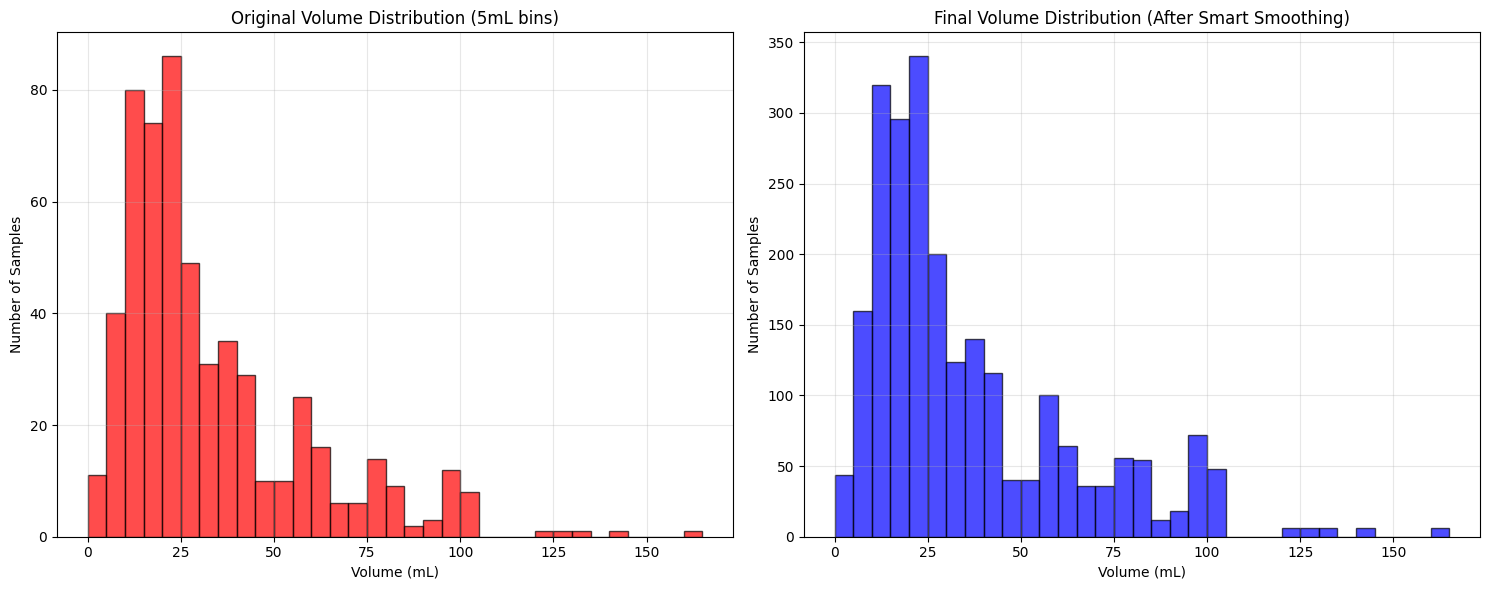

In [13]:
# ====================================================================
# 1. SMART SMOOTHING PROFESSIONAL DATA AUGMENTATION - Eliminates ALL Drops
# ====================================================================

df = df[df["Label"] == 1]  # keep only annotated frames

feature_cols = df.columns[2:66]
seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

# --- SMART Professional Augmentation Functions ---
def add_gaussian_noise(sip, noise_level=0.02):
    """
    Add Gaussian noise with 15% of the maximum possible value (4000).
    This ensures the model can distinguish between real and augmented data.
    """
    max_possible_val = 4000  # Maximum possible sensor value
    std_dev = noise_level * max_possible_val
    noise = np.random.normal(0, std_dev, sip.shape)
    noisy_sip = sip + noise
    return np.clip(noisy_sip, a_min=0.0, a_max=None)

def flip_horizontal(sip):
    """Flip 8x8 frames horizontally for all time steps in sip (T, 64)."""
    flipped = []
    for frame in sip:
        frame_8x8 = frame.reshape(8, 8)
        flipped_frame = np.fliplr(frame_8x8).flatten()
        flipped.append(flipped_frame)
    return np.array(flipped, dtype=np.float32)

def rotate_frame(frame, angle):
    """Rotate a single 8x8 frame by a given angle (in degrees)."""
    from scipy.ndimage import rotate
    frame_8x8 = frame.reshape(8, 8)
    rotated = rotate(frame_8x8, angle, reshape=False, order=1, mode='nearest')
    return rotated.flatten()

def rotate_sip(sip, angle):
    """Rotate all frames in a sip (T, 64) by a given angle (in degrees)."""
    return np.array([rotate_frame(frame, angle) for frame in sip], dtype=np.float32)

def get_rotations(sip, num_rotations=2):
    """
    Return a limited number of rotated versions of sip.
    Using realistic rotation angles for chest-mounted sensor study.
    These angles represent realistic body movements during drinking.
    """
    # Realistic rotation angles for chest-mounted sensor
    # Small movements: 5°, 10°, 15° (realistic body adjustments)
    # Moderate movements: 20°, 30°, 45° (leaning, turning)
    # Large movements: 315°, 330°, 340°, 350°, 355° (counter-rotations)
    realistic_rotation_angles = [5, 355, 10, 350, 20, 340, 30, 330, 45, 315]
    
    # Randomly select angles for diversity
    selected_angles = np.random.choice(realistic_rotation_angles, 
                                     size=min(num_rotations, len(realistic_rotation_angles)), 
                                     replace=False)
    
    return [rotate_sip(sip, angle) for angle in selected_angles]

# --- SMART SMOOTHING Distribution Analysis to Eliminate ALL Drops ---
def analyze_volume_distribution_corrected(y_values, bin_width=5):
    """
    SMART SMOOTHING distribution analysis to eliminate ALL drops and create uniform distribution.
    Uses intelligent targeting to avoid over-augmentation.
    """
    bins = np.arange(0, max(y_values) + bin_width, bin_width)
    hist, bin_edges = np.histogram(y_values, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Calculate statistics
    mean_samples = np.mean(hist[hist > 0])
    median_samples = np.median(hist[hist > 0])
    
    # SMART target: aim for uniform distribution around mean
    target_samples = int(mean_samples * 1.2)  # 20% above mean for safety
    
    # SMART augmentation needs calculation
    augmentation_needs = {}
    
    # First pass: identify ALL problematic drops
    problematic_drops = []
    for i in range(1, len(hist)):
        if hist[i] > 0 and hist[i-1] > 0:
            drop_ratio = hist[i] / hist[i-1]
            if drop_ratio < 0.8:  # More than 20% drop (very sensitive)
                problematic_drops.append((i, drop_ratio))
    
    # Second pass: calculate SMART augmentation needs
    for i, (center, count) in enumerate(zip(bin_centers, hist)):
        if count == 0:  # Empty bins
            augmentation_needs[center] = int(target_samples * 0.8)
        elif count < target_samples * 0.5:  # Severely underrepresented
            augmentation_needs[center] = int(target_samples - count)
        elif count < target_samples * 0.8:  # Moderately underrepresented
            augmentation_needs[center] = int((target_samples - count) * 0.7)
        elif count < target_samples * 1.1:  # Slightly underrepresented
            augmentation_needs[center] = int((target_samples - count) * 0.3)
        else:  # Well represented - minimal augmentation
            augmentation_needs[center] = 0
    
    # Third pass: SMART smoothing of problematic drops
    for drop_idx, drop_ratio in problematic_drops:
        if drop_idx < len(bin_centers):
            center = bin_centers[drop_idx]
            if center in augmentation_needs:
                # Calculate how much we need to smooth the drop
                current_need = augmentation_needs[center]
                # Aim to bring the drop up to 80% of the previous bin
                target_for_drop = int(hist[drop_idx-1] * 0.8)
                additional_need = max(0, target_for_drop - hist[drop_idx])
                augmentation_needs[center] = max(current_need, additional_need)
    
    # Fourth pass: prevent over-augmentation of already high bins
    for center, needed in list(augmentation_needs.items()):
        bin_idx = np.where(bin_centers == center)[0][0]
        current_count = hist[bin_idx]
        if current_count > target_samples * 1.5:  # If already over-augmented
            augmentation_needs[center] = 0  # Stop augmenting this bin
    
    return augmentation_needs, bin_centers, hist, target_samples

def determine_augmentation_strategy_corrected(dV, augmentation_needs, bin_width=5):
    """
    SMART BALANCED augmentation strategy to eliminate ALL drops and create smooth transitions.
    """
    bin_center = int(dV // bin_width) * bin_width + bin_width / 2
    
    # SMART BALANCED approach: intelligent targeting to avoid over-augmentation
    if dV <= 20:  # Low DV ranges - moderate augmentation
        if bin_center in augmentation_needs:
            needed = augmentation_needs[bin_center]
            if needed > 15:
                return {
                    'rotations': 3,  # Balanced rotations
                    'flips': 1,  # Only flip once!
                    'noise_copies': 1,
                    'noise_levels': [0.02]  # Single noise level
                }
            else:
                return {
                    'rotations': 2,
                    'flips': 1,  # Only flip once!
                    'noise_copies': 0,
                    'noise_levels': []
                }
        else:
            return {
                'rotations': 1,  # Minimal rotation
                'flips': 0,
                'noise_copies': 0,
                'noise_levels': []
            }
    
    elif dV > 100:  # High DV ranges - moderate augmentation
        if bin_center in augmentation_needs:
            needed = augmentation_needs[bin_center]
            return {
                'rotations': 3,  # Balanced rotations
                'flips': 1,  # Only flip once!
                'noise_copies': 1,
                'noise_levels': [0.02]  # Single noise level
            }
        else:
            return {
                'rotations': 2,
                'flips': 1,  # Only flip once!
                'noise_copies': 0,
                'noise_levels': []
            }
    
    elif dV > 60:  # Medium-high DV ranges
        if bin_center in augmentation_needs:
            needed = augmentation_needs[bin_center]
            if needed > 10:
                return {
                    'rotations': 3,
                    'flips': 1,  # Only flip once!
                    'noise_copies': 1,
                    'noise_levels': [0.02]
                }
            else:
                return {
                    'rotations': 2,
                    'flips': 1,  # Only flip once!
                    'noise_copies': 0,
                    'noise_levels': []
                }
        else:
            return {
                'rotations': 1,
                'flips': 0,
                'noise_copies': 0,
                'noise_levels': []
            }
    
    else:  # Medium DV ranges (20-60) - SMART targeting of drops
        if bin_center in augmentation_needs:
            needed = augmentation_needs[bin_center]
            if needed > 15:
                return {
                    'rotations': 3,  # Balanced rotations for problematic areas
                    'flips': 1,  # Only flip once!
                    'noise_copies': 1,
                    'noise_levels': [0.02]
                }
            else:
                return {
                    'rotations': 2,
                    'flips': 1,  # Only flip once!
                    'noise_copies': 0,
                    'noise_levels': []
                }
        else:
            return {
                'rotations': 1,  # Minimal rotation
                'flips': 0,
                'noise_copies': 0,
                'noise_levels': []
            }

# --- Main Smart Smoothing Professional Augmentation Pipeline ---
X, y, is_original = [], [], []
y_before_aug = []
skip_count = 0

# First pass: collect original data
original_data = []
for _, g in df.groupby(seq_keys, sort=False):
    dV = float(g[label_col].iloc[0])
    if dV == 0.0:
        skip_count += 1
        continue
    
    sip_frames = g[feature_cols].to_numpy(np.float32)
    original_data.append((sip_frames, dV))

# Smart smoothing distribution analysis with 5mL bins
original_volumes = [data[1] for data in original_data]
bin_width = 5  # 5mL bins for better detail as requested
augmentation_needs, bin_centers, hist, target_samples = analyze_volume_distribution_corrected(original_volumes, bin_width)

print("=== SMART SMOOTHING PROFESSIONAL Volume Distribution Analysis ===")
print(f"Original samples: {len(original_data)}")
print(f"Target samples per bin: {target_samples}")
print(f"Peak samples: {np.max(hist)}")
print(f"Mean samples per bin: {np.mean(hist[hist > 0]):.1f}")
print(f"Median samples per bin: {np.median(hist[hist > 0]):.1f}")

print("\nVolume bins and sample counts (5mL bins):")
for center, count in zip(bin_centers, hist):
    if count > 0:
        print(f"  {center-bin_width/2:.1f}-{center+bin_width/2:.1f} mL: {count} samples")

print("\nAugmentation needs (SMART targeting of drops):")
for center, needed in augmentation_needs.items():
    print(f"  {center-bin_width/2:.1f}-{center+bin_width/2:.1f} mL: need {needed} more samples")

# Second pass: apply smart smoothing professional augmentation
augmentation_count = 0
low_dv_augmented = 0
high_dv_augmented = 0
medium_dv_augmented = 0

for sip_frames, dV in original_data:
    # Add original sample
    X.append(sip_frames)
    y.append(dV)
    y_before_aug.append(dV)
    is_original.append(True)
    
    # Determine smart smoothing augmentation strategy
    strategy = determine_augmentation_strategy_corrected(dV, augmentation_needs, bin_width)
    
    # Track augmentation by volume range
    if dV <= 20:
        range_type = "low"
    elif dV > 100:
        range_type = "high"
    else:
        range_type = "medium"
    
    # Apply rotations with realistic angles
    if strategy['rotations'] > 0:
        rotations = get_rotations(sip_frames, strategy['rotations'])
        for rotated in rotations:
            X.append(rotated)
            y.append(dV)
            is_original.append(False)
            augmentation_count += 1
            if range_type == "low":
                low_dv_augmented += 1
            elif range_type == "high":
                high_dv_augmented += 1
            else:
                medium_dv_augmented += 1
    
    # Apply flips (ONLY ONCE per sample!)
    if strategy['flips'] > 0:
        flipped = flip_horizontal(sip_frames)
        X.append(flipped)
        y.append(dV)
        is_original.append(False)
        augmentation_count += 1
        if range_type == "low":
            low_dv_augmented += 1
        elif range_type == "high":
            high_dv_augmented += 1
        else:
            medium_dv_augmented += 1
    
    # Apply noise with appropriate levels
    for _ in range(strategy['noise_copies']):
        for noise_level in strategy['noise_levels']:
            noisy = add_gaussian_noise(sip_frames, noise_level)
            X.append(noisy)
            y.append(dV)
            is_original.append(False)
            augmentation_count += 1
            if range_type == "low":
                low_dv_augmented += 1
            elif range_type == "high":
                high_dv_augmented += 1
            else:
                medium_dv_augmented += 1

# Final conversion to array
X = np.array(X, dtype=object)
y = np.array(y, dtype=np.float32)
y_before_aug = np.array(y_before_aug, dtype=np.float32)
is_original_1 = np.array(is_original, dtype=bool)

print(f"\n=== SMART SMOOTHING PROFESSIONAL Dataset Statistics ===")
print(f"Total sips kept (including augmented): {len(X)}")
print(f"Zero-volume skipped: {skip_count}")
print(f"Label stats → min: {min(y):.1f}, max: {max(y):.1f}")
print(f"Original sips: {np.sum(is_original_1)}, Augmented sips: {np.sum(~is_original_1)}")
print(f"Augmentation ratio: {np.sum(~is_original_1) / np.sum(is_original_1):.2f}x")
print(f"Total augmentations applied: {augmentation_count}")

print(f"\n=== Augmentation by Volume Range ===")
print(f"Low DV (≤20mL) augmentations: {low_dv_augmented}")
print(f"Medium DV (21-100mL) augmentations: {medium_dv_augmented}")
print(f"High DV (>100mL) augmentations: {high_dv_augmented}")

# Verify the new distribution is more balanced
final_volumes = y
final_hist, _ = np.histogram(final_volumes, bins=bin_centers)

print("\nFinal distribution after smart smoothing professional augmentation (5mL bins):")
for center, count in zip(bin_centers, final_hist):
    if count > 0:
        print(f"  {center-bin_width/2:.1f}-{center+bin_width/2:.1f} mL: {count} samples")

# Calculate distribution improvement metrics
original_std = np.std(hist[hist > 0])
final_std = np.std(final_hist[final_hist > 0])
improvement = (original_std - final_std) / original_std * 100

print(f"\n=== Distribution Balance Metrics ===")
print(f"Original distribution std: {original_std:.2f}")
print(f"Final distribution std: {final_std:.2f}")   
print(f"Balance improvement: {improvement:.1f}%")

# Additional metrics
original_cv = original_std / np.mean(hist[hist > 0])  # Coefficient of variation
final_cv = final_std / np.mean(final_hist[final_hist > 0])
cv_improvement = (original_cv - final_cv) / original_cv * 100

print(f"Original CV: {original_cv:.3f}")
print(f"Final CV: {final_cv:.3f}")
print(f"CV improvement: {cv_improvement:.1f}%")

# Plot comparison with 5mL bins
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Original distribution
bins = np.arange(0, max(original_volumes) + bin_width, bin_width)
ax1.hist(original_volumes, bins=bins, alpha=0.7, color='red', edgecolor='black')
ax1.set_title('Original Volume Distribution (5mL bins)')
ax1.set_xlabel('Volume (mL)')
ax1.set_ylabel('Number of Samples')
ax1.grid(True, alpha=0.3)

# Final distribution
ax2.hist(final_volumes, bins=bins, alpha=0.7, color='blue', edgecolor='black')
ax2.set_title('Final Volume Distribution (After Smart Smoothing)')
ax2.set_xlabel('Volume (mL)')
ax2.set_ylabel('Number of Samples')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

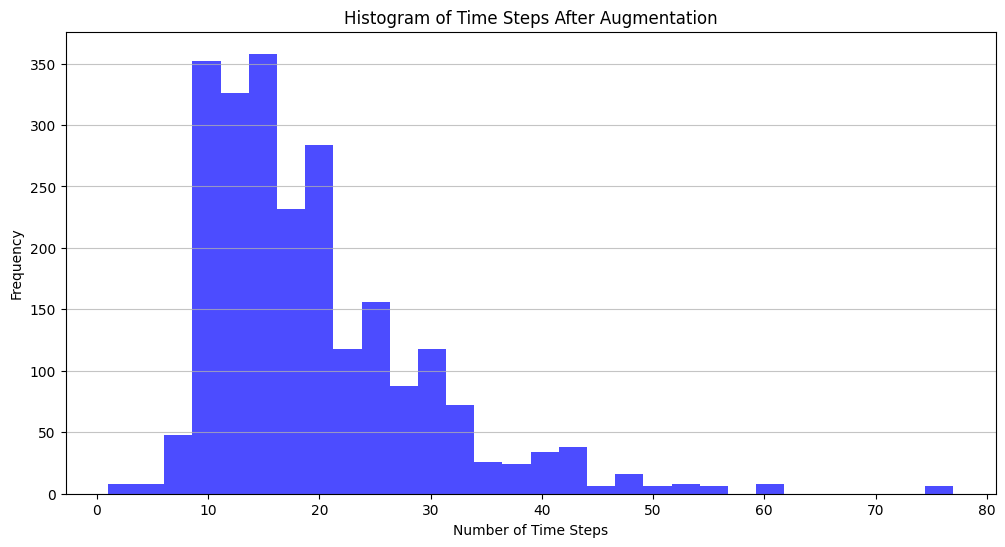

In [14]:
import matplotlib.pyplot as plt

# Get time step lengths for all sips
time_steps = [sip.shape[0] for sip in X]  # X is your final data after augmentation

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(time_steps, bins=30, alpha=0.7, color='blue')
plt.title('Histogram of Time Steps After Augmentation')
plt.xlabel('Number of Time Steps')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


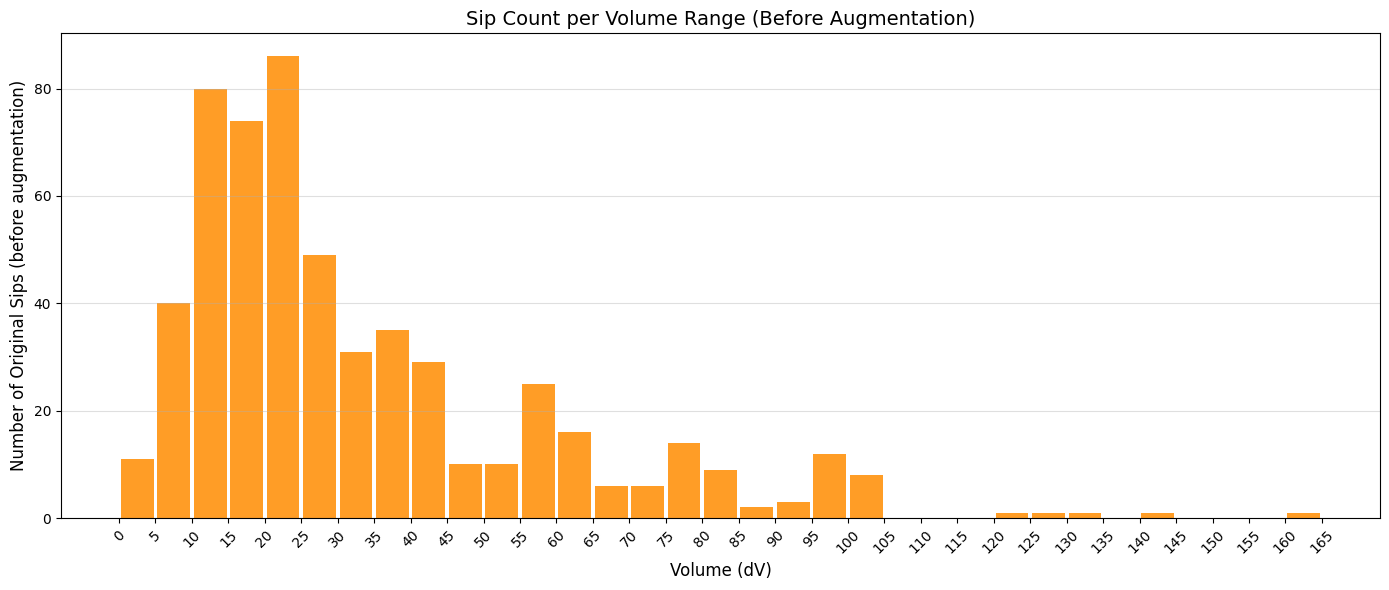

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Create a fresh list for original (pre-augmentation) volumes
original_volumes = []

for _, g in df.groupby(["Participant_ID", "sip_id"], sort=False):
    dV = float(g["dV"].iloc[0])
    if dV == 0.0:
        continue
    original_volumes.append(dV)  # Only original sips, no augmentation

# Convert to NumPy array
original_volumes = np.array(original_volumes)

# --- Parameters ---
bin_width = 5  # mL
min_vol = int(np.floor(min(original_volumes) / bin_width) * bin_width)
max_vol = int(np.ceil(max(original_volumes) / bin_width) * bin_width)

# Create bins (e.g., [0, 5, 10, ..., 100])
volume_bins = np.arange(min_vol, max_vol + bin_width, bin_width)

# Digitize original_volumes into bins
bin_indices = np.digitize(original_volumes, volume_bins)
bin_counts = [0] * (len(volume_bins) - 1)

# Count how many original sips fall into each bin
for idx in bin_indices:
    if 1 <= idx < len(volume_bins):
        bin_counts[idx - 1] += 1

# Bin centers
bin_centers = [(volume_bins[i] + volume_bins[i + 1]) / 2 for i in range(len(volume_bins) - 1)]

# Create DataFrame for export
df_export = pd.DataFrame({
    'Volume_Range': [f"{volume_bins[i]}-{volume_bins[i+1]}" for i in range(len(volume_bins)-1)],
    'Bin_Center': bin_centers,
    'Sip_Count': bin_counts
})

# Export to Excel
df_export.to_excel('sip_volume_distribution_before_augmentation.xlsx', index=False)

# --- Plot ---
plt.figure(figsize=(14, 6))
plt.bar(bin_centers, bin_counts, width=bin_width * 0.9, color='darkorange', alpha=0.85)
plt.xlabel('Volume (dV)', fontsize=12)
plt.ylabel('Number of Original Sips (before augmentation)', fontsize=12)
plt.title('Sip Count per Volume Range (Before Augmentation)', fontsize=14)
plt.grid(axis='y', alpha=0.4)
plt.xticks(np.arange(min_vol, max_vol + 1, bin_width), rotation=45)
plt.tight_layout()
plt.show()


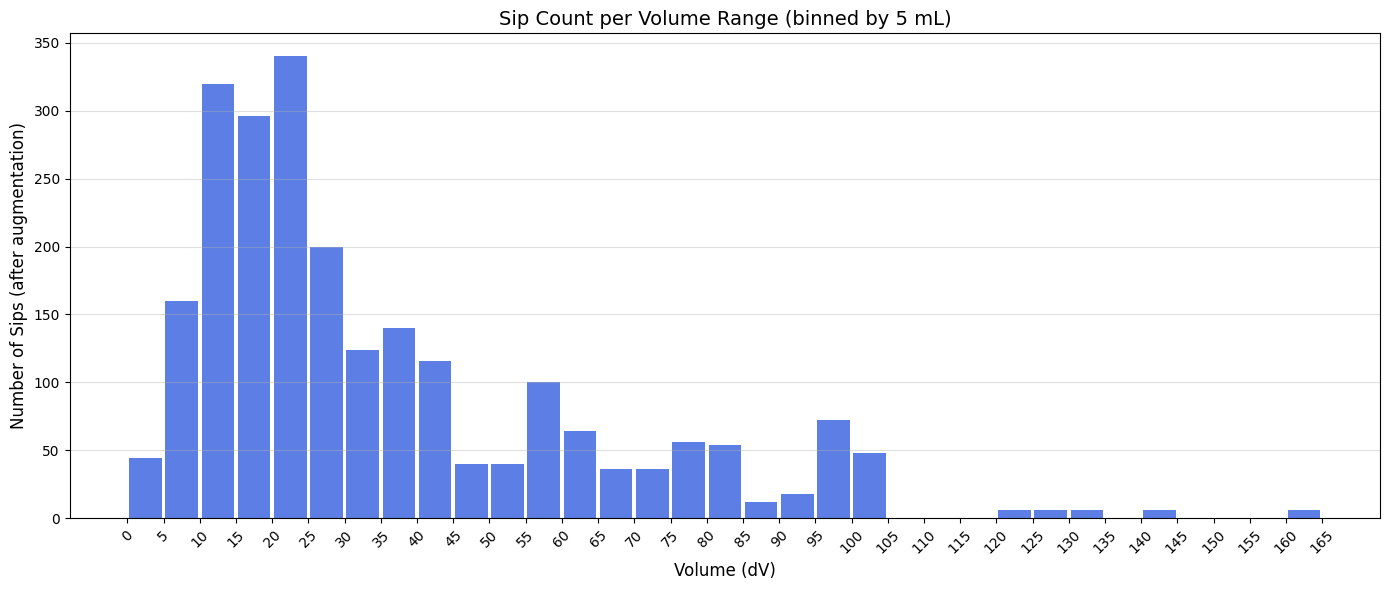

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# --- Parameters ---
bin_width = 5  # mL
min_vol = int(np.floor(min(y) / bin_width) * bin_width)
max_vol = int(np.ceil(max(y) / bin_width) * bin_width)

# Create bins (e.g., [0, 5, 10, ..., 100])
volume_bins = np.arange(min_vol, max_vol + bin_width, bin_width)

# Digitize y into bins
bin_indices = np.digitize(y, volume_bins)  # assigns bin index
bin_counts = [0] * (len(volume_bins) - 1)

# Count how many sips fall into each bin
for idx in bin_indices:
    if 1 <= idx < len(volume_bins):  # skip out-of-range
        bin_counts[idx - 1] += 1

# Bin labels: midpoint of each bin (e.g., 2.5, 7.5, ...)
bin_centers = [(volume_bins[i] + volume_bins[i + 1]) / 2 for i in range(len(volume_bins) - 1)]

# Create DataFrame for export
df_export = pd.DataFrame({
    'Volume_Range': [f"{volume_bins[i]}-{volume_bins[i+1]}" for i in range(len(volume_bins)-1)],
    'Bin_Center': bin_centers,
    'Sip_Count': bin_counts
})

# Export to Excel
df_export.to_excel('sip_volume_distribution_after_augmentation.xlsx', index=False)

# --- Plot ---
plt.figure(figsize=(14, 6))
plt.bar(bin_centers, bin_counts, width=bin_width * 0.9, color='royalblue', alpha=0.85)
plt.xlabel('Volume (dV)', fontsize=12)
plt.ylabel('Number of Sips (after augmentation)', fontsize=12)
plt.title('Sip Count per Volume Range (binned by 5 mL)', fontsize=14)
plt.grid(axis='y', alpha=0.4)
plt.xticks(np.arange(min_vol, max_vol + 1, bin_width), rotation=45)
plt.tight_layout()
plt.show()


In [17]:
X[:1]

array([array([[2487.,  165.,  348., ...,  364.,  330., 1817.],
              [2487.,  165.,  348., ...,  364.,  330., 1817.],
              [ 265.,  200.,  234., ...,  364.,  352., 1817.],
              ...,
              [ 304., 2267., 2300., ...,  331., 1449., 1140.],
              [ 299., 2267., 2300., ...,  352.,  352., 1151.],
              [ 295., 2280., 2300., ...,  352., 1449., 1151.]], dtype=float32)],
      dtype=object)

In [18]:
print(type(X))          # <class 'numpy.ndarray'>
print(X.shape)          # (number,)

print(type(X[0]))       # <class 'numpy.ndarray'>
print(X[0].shape)       # (rows, columns)

<class 'numpy.ndarray'>
(2346,)
<class 'numpy.ndarray'>
(26, 64)


In [19]:
# # ====================================================================
# # 2. shuffle whole sips ➜ 80 / 20 split
# # ====================================================================
# original_indices = np.array([i for i, orig in enumerate(is_original) if orig])
# augmented_indices = np.array([i for i, orig in enumerate(is_original) if not orig])


# idx = rng.permutation(len(X))
# split1 = int(.64 * len(X))          # 64 % train
# split2 = int(.80 * len(X))          # next 16 % val
# X_train, y_train = X[idx[:split1]], y[idx[:split1]]
# X_val,   y_val   = X[idx[split1:split2]], y[idx[split1:split2]]
# X_test,  y_test  = X[idx[split2:]], y[idx[split2:]]
# print(f"Train {len(X_train)} Val {len(X_val)}  Test {len(X_test)}")
# # y_train_s = np.log1p(y_train)        # log1p for numerical safety
# # y_val_s   = np.log1p(y_val)
# # y_test_s  = np.log1p(y_test)


In [20]:
# ====================================================================
# 2. shuffle whole sips ➜ 80 / 20 split (test set = only original data)
# ====================================================================
# Identify indices for original and augmented samples
original_indices = np.array([i for i, orig in enumerate(is_original) if orig])
augmented_indices = np.array([i for i, orig in enumerate(is_original) if not orig])

# Shuffle original indices for splitting test set
shuffled = rng.permutation(original_indices)
split1 = int(.8 * len(shuffled))  # 80% train/val, 20% test

test_idx = shuffled[split1:]
trainval_idx = np.concatenate([shuffled[:split1], augmented_indices])

# Now build your splits
X_test, y_test = X[test_idx], y[test_idx]
X_trainval, y_trainval = X[trainval_idx], y[trainval_idx]

# Further split trainval into train/val (e.g., 80/20)
idx_tv = rng.permutation(len(X_trainval))
split_tv = int(.8 * len(X_trainval))
X_train, y_train = X_trainval[idx_tv[:split_tv]], y_trainval[idx_tv[:split_tv]]
X_val, y_val = X_trainval[idx_tv[split_tv:]], y_trainval[idx_tv[split_tv:]]

print(f"Train {len(X_train)} Val {len(X_val)}  Test {len(X_test)}")
# y_train_s = np.log1p(y_train)        # log1p for numerical safety
# y_val_s   = np.log1p(y_val)
# y_test_s  = np.log1p(y_test)

Train 1786 Val 447  Test 113


In [21]:
print("Original data:", sum(is_original))
print("Augmented data:", len(is_original) - sum(is_original))
print("Total data:", len(is_original))
print(len(X), len(y), len(is_original))
print("Total sips kept (including augmented):", len(X))
print("Zero-volume skipped :", skip_count)
print("Label stats  → min:", np.min(y), "max:", np.max(y))
print("is_original length:", len(is_original))
print("Original data:", sum(is_original))
print("Augmented data:", len(is_original) - sum(is_original))
print("Total data (is_original):", len(is_original))
print("len(X):", len(X))
print("len(y):", len(y))
print("len(is_original):", len(is_original))

Original data: 561
Augmented data: 1785
Total data: 2346
2346 2346 2346
Total sips kept (including augmented): 2346
Zero-volume skipped : 2
Label stats  → min: 0.8 max: 160.2
is_original length: 2346
Original data: 561
Augmented data: 1785
Total data (is_original): 2346
len(X): 2346
len(y): 2346
len(is_original): 2346


In [22]:
# X_train


In [23]:
# y_train

In [24]:
# ====================================================================
# 3. column-wise z-score normalisation (fit on training only)
# ====================================================================
mat_train = np.vstack(X_train)          # ⬅ only TRAIN data
mean64 = mat_train.mean(0, keepdims=True)
std64  = mat_train.std(0,  keepdims=True) + 1e-8

norm = lambda seq: (seq - mean64) / std64
X_train = [norm(s) for s in X_train]
X_val   = [norm(s) for s in X_val]
X_test  = [norm(s) for s in X_test]

# # label scaling
# y_max   = y_train.max() or 1.
# y_train_s = y_train / y_max
# y_val_s   = y_val   / y_max
# y_test_s  = y_test  / y_max
y_train_s = y_train 
y_val_s   = y_val   
y_test_s  = y_test  



In [25]:
# X_train

In [26]:
# ====================================================================
# 4. tf.data pipelines
# ====================================================================
def generator(xs, ys):
    for x, y in zip(xs, ys):
        yield x, y

output_sig = (
    tf.TensorSpec((None, 64), tf.float32),
    tf.TensorSpec((),          tf.float32)
)

def make_ds(xs, ys, shuffle=True):
    ds = tf.data.Dataset.from_generator(lambda: generator(xs, ys),
                                        output_signature=output_sig)
    if shuffle:
        ds = ds.shuffle(len(xs), seed=42)
    if BATCH == 1:
        return ds.repeat().batch(1)              # ragged
    return ds.repeat().padded_batch(             # padded
        BATCH,
        padded_shapes=([None, 64], []),
        padding_values=(0.0, 0.0)
    )

train_ds = make_ds(X_train, y_train_s, shuffle=True)
val_ds   = make_ds(X_val,   y_val_s,   shuffle=False)
test_ds  = make_ds(X_test,  y_test_s,  shuffle=False)

In [27]:
train_ds

<_PaddedBatchDataset element_spec=(TensorSpec(shape=(None, None, 64), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>

In [28]:
# for batch in train_ds.take(1):
#     x_batch, y_batch = batch
#     print("x_batch shape:", x_batch.shape)
#     print("y_batch shape:", y_batch.shape)
#     print("x_batch:", x_batch.numpy())
#     print("y_batch:", y_batch.numpy())

In [29]:
# ====================================================================
# 5. model  – TCN ➜ Dense(1, softplus) keeps output ≥ 0
# ====================================================================
inp = tf.keras.Input(shape=(None, 64))
x = TCN(nb_filters=128,
        kernel_size=3,
        dilations=[1,2,4,8,16,32,64],   # ~64-time-step field
        dropout_rate=0.1,
        return_sequences=False)(inp)
out = tf.keras.layers.Dense(1)(x)          # ← LINEAR output
model = tf.keras.Model(inp, out)

model.compile(
    optimizer=Adagrad(learning_rate=0.01),
    loss="mae"                             # MAE is more robust
)
model.summary()

steps_per_epoch = len(X_train) // BATCH + (len(X_train) % BATCH > 0)
val_steps       = len(X_val)   // BATCH + (len(X_val)   % BATCH > 0)
# weights = (y_train / y_train.max()) ** 0.5  
cb = tf.keras.callbacks.EarlyStopping(
         monitor='val_loss', patience=50, restore_best_weights=True)
model.fit(
    train_ds,
    epochs=500,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,        # ⬅ use VALIDATION set
    validation_steps=val_steps,
    verbose=1,
    # sample_weight=weights,
    callbacks=[cb]
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn (TCN)                       │ (None, 128)            │       673,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,793 (2.57 MB)

 Trainable params: 673,793 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
224/224 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 23.0632 - val_loss: 17.4932
Epoch 2/500
224/224 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 15.6723 - val_loss: 15.9625
Epoch 3/500
224/224 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 15.3578 - val_loss: 17.5446
Epoch 4/500
224/224 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 14.4135 - val_loss: 15.1771
Epoch 5/500
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 12.8510 - val_loss: 15.0212
Epoch 6/500
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 13.3353 - val_loss: 14.6110
Epoch 7/500
224/224 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 12.7689 - val_loss: 14.2486
Epoch 8/500
224/224 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 12.0794 - val_loss: 14.3628
Epoch 9/500
224/224 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 12.1644 - val_loss: 14.6713
Epoch 10/500
224/224 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 11.7971 - val_loss: 13.2807
Epoch 11/500
224/224 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 11.0353 - val_loss: 13.5988
Epoch 12

In [30]:
# ====================================================================
# 6. inference on test set (un-scale predictions)
# ====================================================================
y_pred_s = np.array([model.predict(seq[None, ...], verbose=0)[0, 0]
                     for seq in X_test])
# inverse transform after prediction
# y_pred_s = np.expm1(y_pred_s)
# y_pred   = y_pred_s * y_max
y_pred = y_pred_s
y_mean, y_std = y_train.mean(), y_train.std()
y_train_s = (y_train - y_mean) / y_std
# ...
# y_pred = y_pred_s * y_std + y_mean       # undo scaling

In [31]:
# ====================================================================
# 7. evaluation
# ====================================================================
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

non_zero = y_test != 0
rmspe = (np.sqrt(np.mean(((y_test[non_zero]-y_pred[non_zero]) /
                          y_test[non_zero])**2))*100
         if non_zero.any() else np.nan)

print(f"\nEvaluation on {len(y_test)} test sips")
print(f"  MSE   : {mse:.4f}")
print(f"  RMSE  : {rmse:.4f}")
print(f"  R²    : {r2:.4f}")
print(f"  RMSPE : {rmspe:.2f}%")

comparison_df = pd.DataFrame({"Actual dV": y_test, "Predicted dV": y_pred})
print("\nFirst 50 predictions:")
print(comparison_df.head(50))


Evaluation on 113 test sips
  MSE   : 115.3665
  RMSE  : 10.7409
  R²    : 0.8276
  RMSPE : 57.32%

First 50 predictions:
     Actual dV  Predicted dV
0    38.393730     24.528679
1    21.900000     22.748026
2   100.000000     93.958771
3    13.320274     13.594219
4    39.177277     40.203972
5    25.661116     22.130909
6    28.000000     19.055473
7    13.900000     21.390226
8    87.800003     87.529144
9    14.624506     11.531858
10   10.476191     21.538507
11   37.599998     14.081182
12   59.523811     51.775951
13   26.052889     38.627247
14   13.523809     10.627779
15   62.095238     54.754913
16   73.500000     49.790440
17   39.682541     39.995491
18   20.000000     41.878075
19   39.177277     42.533783
20   63.173359     40.667046
21   14.201763     13.467216
22    2.938296      6.832664
23   12.327416     10.401590
24   42.190475     21.064875
25   24.007936     14.075990
26   23.523809     30.783392
27   11.706349     11.592249
28   17.400000     13.756310
29   33

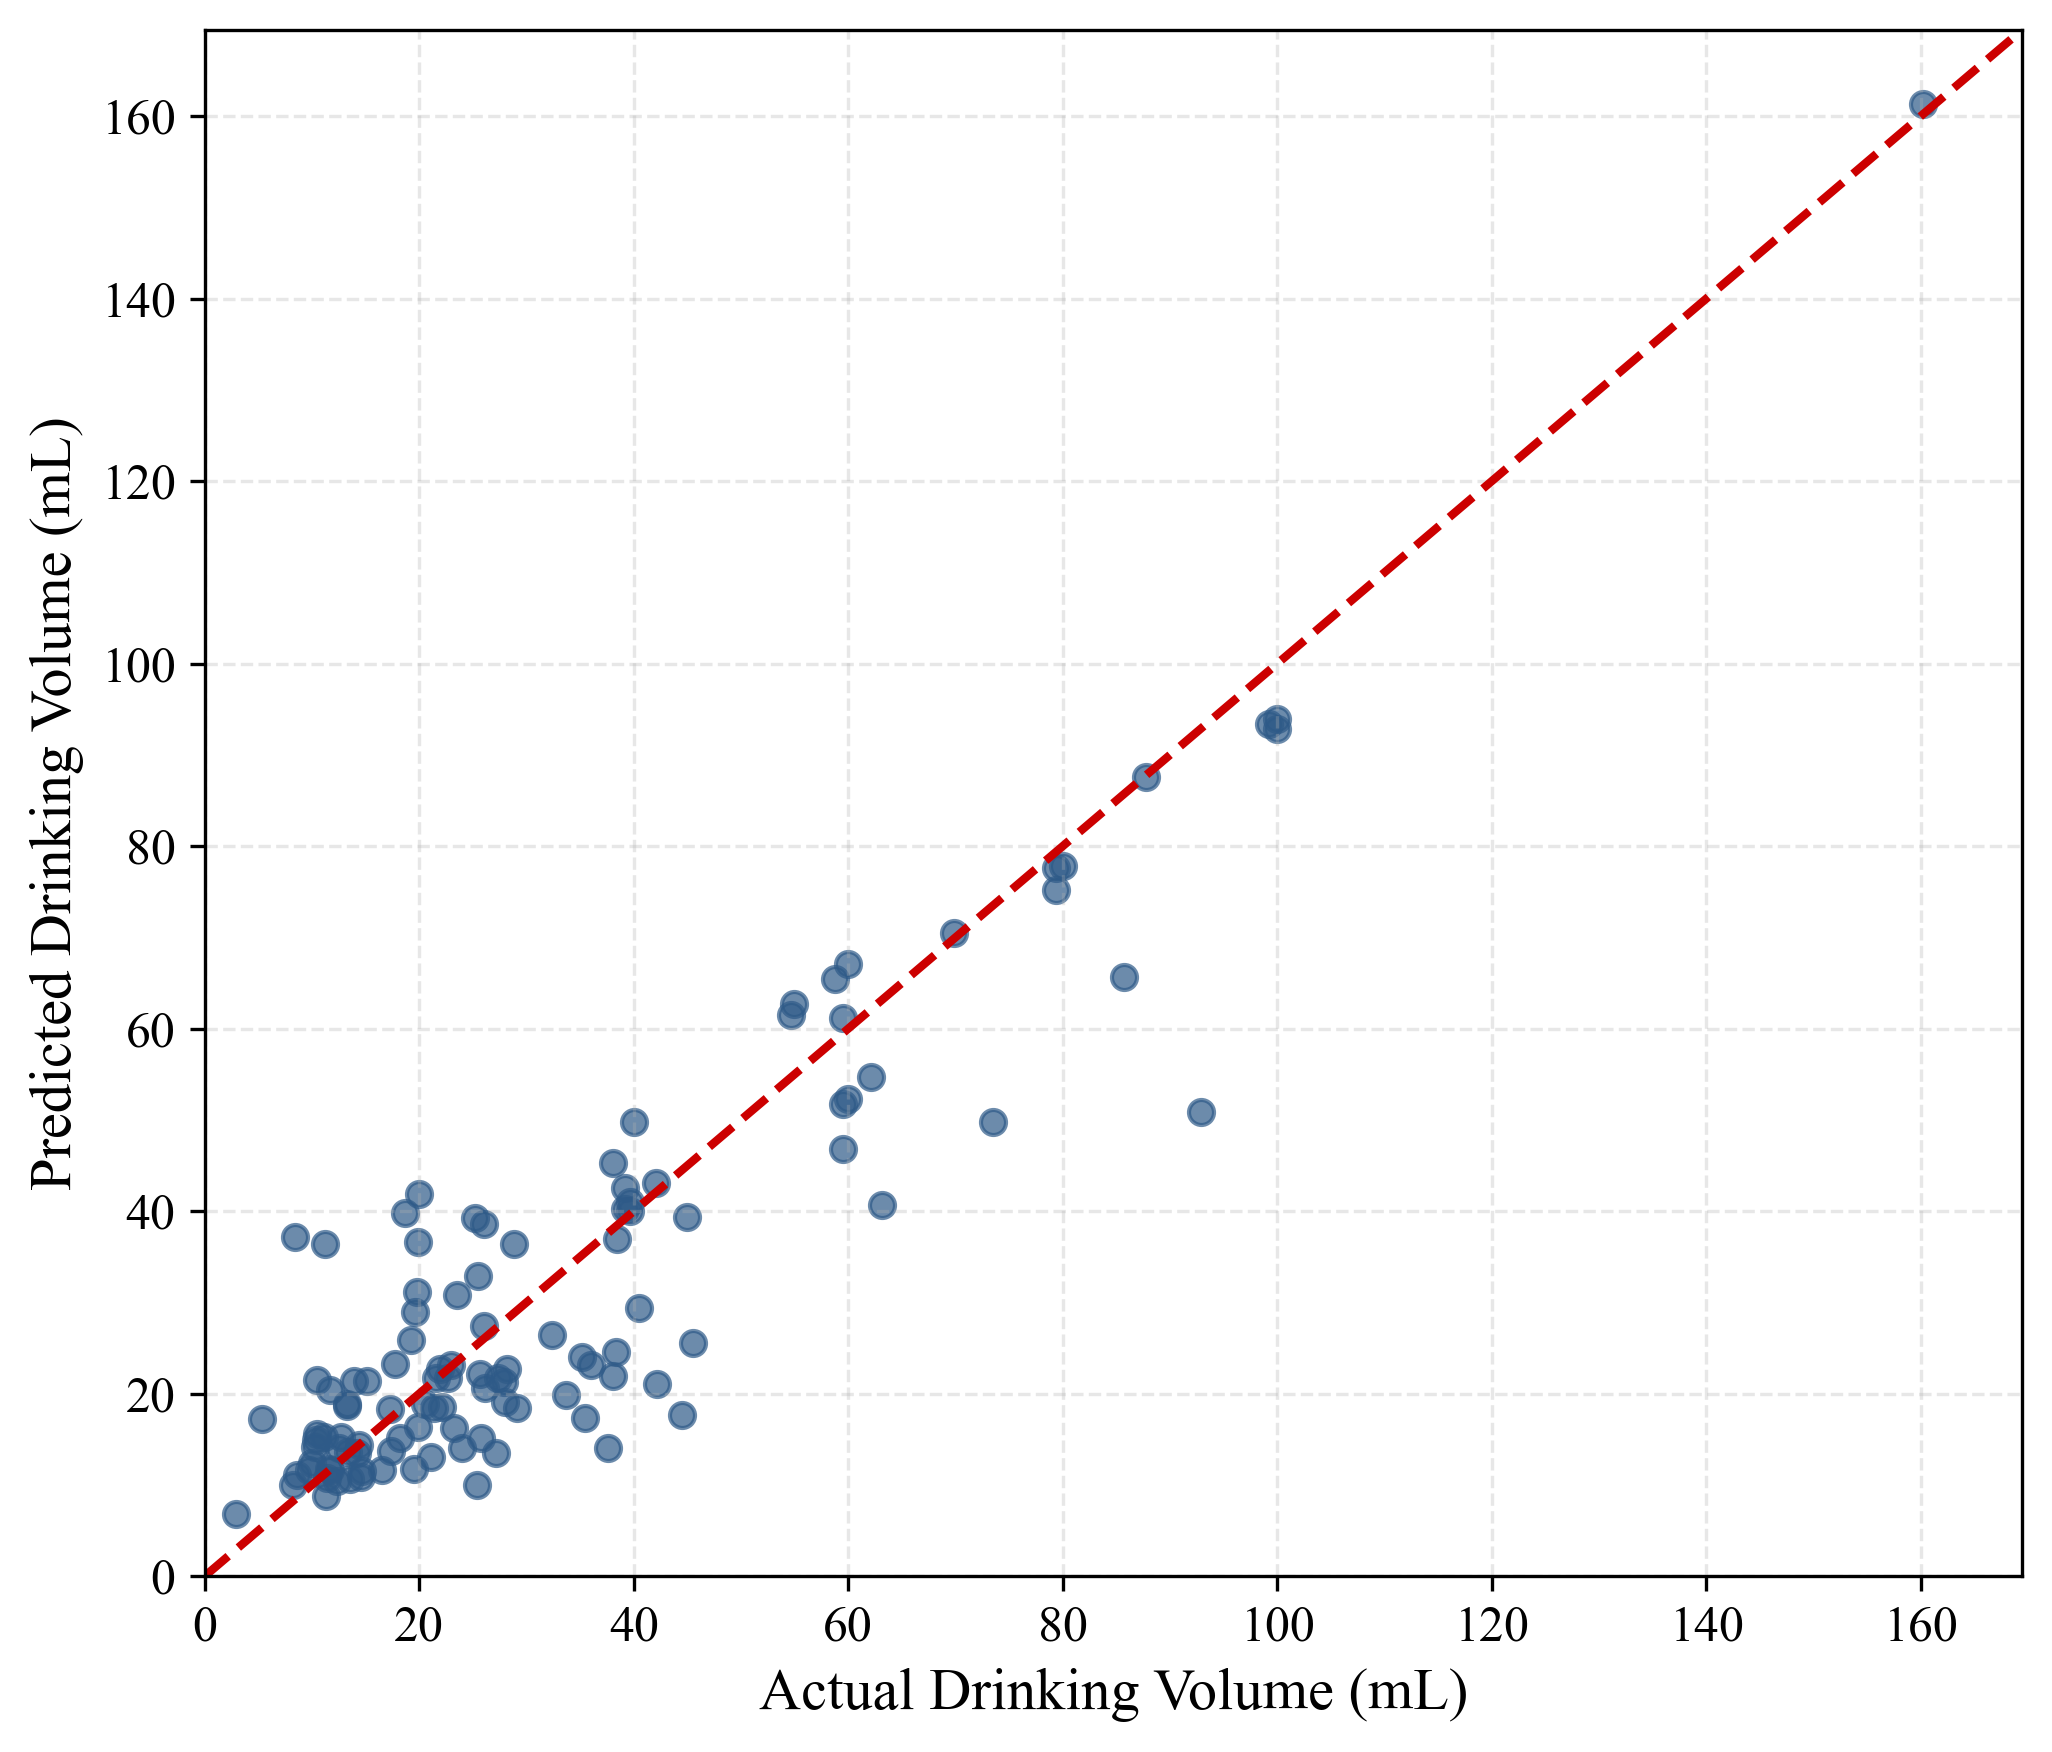

Results saved to 'tcn_predictions_both_regression.xlsx'
Plots saved as 'drinking_volume_prediction.pdf' and 'drinking_volume_prediction.png'


In [32]:
# ====================================================================
# 8. scatter plot and save data
# ====================================================================
plt.figure(figsize=(7, 6), dpi=300)  # Higher DPI for publication quality
plt.rcParams.update({
    'font.family': 'Times New Roman',  # Standard academic font
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

plt.scatter(y_test, y_pred, alpha=0.7, color='#2E5A88')  # Professional blue color
lims = [0, max(y_test.max(), y_pred.max()) * 1.05]
plt.plot(lims, lims, "--", color='#CC0000', linewidth=2)  # Darker red for clarity
plt.xlim(lims); plt.ylim(lims)

plt.xlabel("Actual Drinking Volume (mL)")
plt.ylabel("Predicted Drinking Volume (mL)")
# Removed title for academic publication - figure caption will be used instead

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# Save high-quality figure for publication
plt.savefig('drinking_volume_prediction.pdf', format='pdf', bbox_inches='tight')
plt.savefig('drinking_volume_prediction.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# Save predictions to Excel file for Tableau
results_df = pd.DataFrame({
    'Actual_Volume': y_test,
    'Predicted_Volume': y_pred
})
results_df.to_excel('tcn_predictions_both_regression.xlsx', index=False)
print("Results saved to 'tcn_predictions_both_regression.xlsx'")
print("Plots saved as 'drinking_volume_prediction.pdf' and 'drinking_volume_prediction.png'")